# Phase 1: Phishing Detection

Github Repo: https://github.com/LamaMiners/dsai-mlops
Github Pages: https://lamaminers.github.io/dsai-mlops/

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import json

df = pd.read_csv('phishing_dataset.csv')

## 1. Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524846 entries, 0 to 524845
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   num_words            524846 non-null  int64
 1   num_unique_words     524846 non-null  int64
 2   num_stopwords        524846 non-null  int64
 3   num_links            524846 non-null  int64
 4   num_unique_domains   524846 non-null  int64
 5   num_email_addresses  524846 non-null  int64
 6   num_spelling_errors  524846 non-null  int64
 7   num_urgent_keywords  524846 non-null  int64
 8   label                524846 non-null  int64
dtypes: int64(9)
memory usage: 36.0 MB
None
          num_words  num_unique_words  num_stopwords      num_links  \
count  5.248460e+05     524846.000000  524846.000000  524846.000000   
mean   2.762280e+02        123.012167      80.045465       0.895588   
std    3.335457e+03        201.626478    1023.330380       5.603001   
min    0.000000e+00    

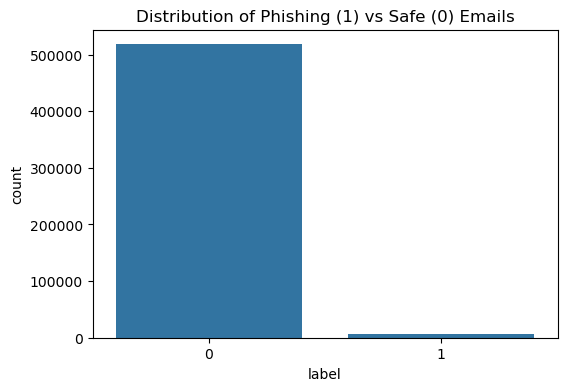

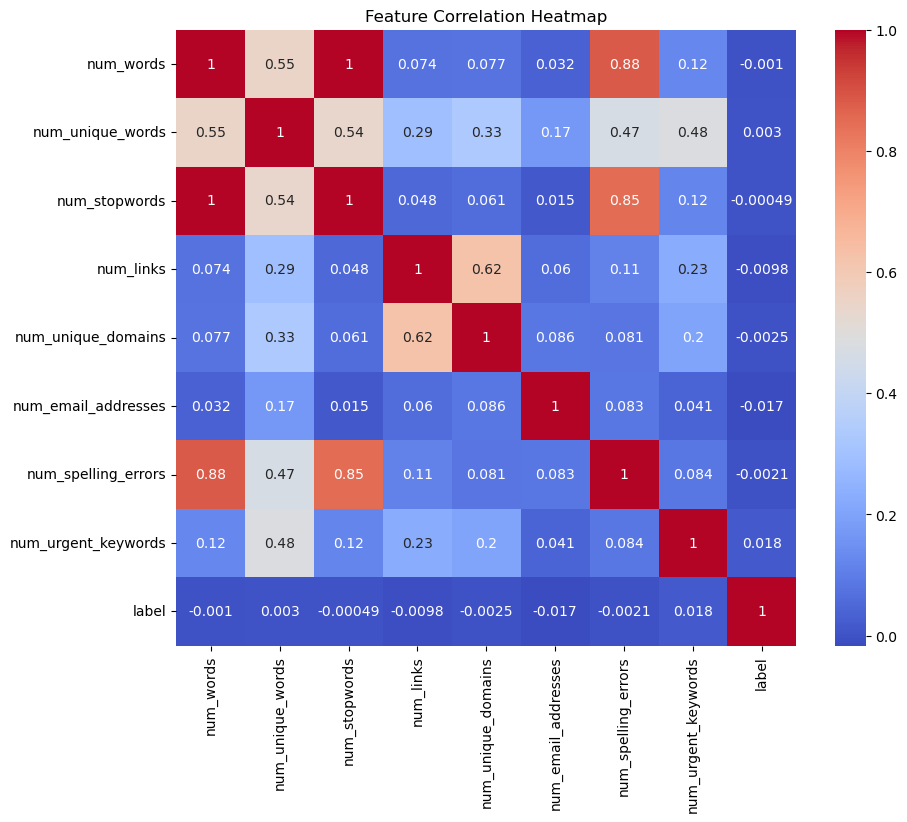

In [4]:
print(df.info())
print(df.describe())

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Phishing (1) vs Safe (0) Emails')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 2. Data Preparation

In [6]:
features = ['num_words', 'num_unique_words', 'num_stopwords', 'num_links', 
            'num_unique_domains', 'num_email_addresses', 'num_spelling_errors', 'num_urgent_keywords']
X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Training & Evaluation

In [8]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

Accuracy: 0.5356
F1-Score: 0.0421


## 4. Export for ML.js

In [10]:
model_data = {
    "coef": model.coef_[0].tolist(),
    "intercept": float(model.intercept_[0]),
    "feature_names": features
}

with open("model.json", "w") as f:
    json.dump(model_data, f)